This notebook plots Fig. 4A-D and S6A-G plots.

The notebook uses positive TF regulator input from "9. Multiome 5 - input preparation for Fig. 4A-D and S6A-G" (proj_alpha_corGEM_MM.csv, proj_skeletal_ctl_corGEM_MM.csv, proj_control_FF_Int_SF_corGEM_MM.csv) along with additional inputs. See "11. Multiome & snRNA-seq 1 - input preparation (cross-modal label transfer, multiome RNA differential expression)" for creation of alpha_label_transfer_50.rds.

## Setup

In [1]:
# Paths
SOD1_RENV_MULTIOME <- "/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-Multiome/"
SOD1_MULTIOME_DIR  <- "/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome"
SOD1_RNA_DIR <- "/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA"
CELLORACLE_DIR <- "/oak/stanford/groups/agitler/Thao/dockers/CellOracle/celloracle_data/CellOracle_figures"

renv::load(SOD1_RENV_MULTIOME)
Sys.setenv(SOD1_MULTIOME_DIR = SOD1_MULTIOME_DIR)

# Packages
suppressPackageStartupMessages({
  pkgs <- c(
    "ArchR", "future", "dplyr", "BSgenome.Mmusculus.UCSC.mm10",
    "pheatmap", "ggpubr", "ggrepel", "ggbreak", "cowplot",
    "Seurat", "forcats", "ggrastr"
  )
  invisible(lapply(pkgs, library, character.only = TRUE))
})

# ArchR / future settings
addArchRGenome("mm10")
addArchRThreads(threads = 16)

plan(strategy = "multicore", workers = 16)
options(future.globals.maxSize = 41953040000)

# ArchR project paths
project_path <- function(name) file.path(SOD1_MULTIOME_DIR, name)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## DM/DAMN-status plots

### Positive TF regulators plot

Warning message:
“Removed 140 rows containing missing values (`geom_point()`).”
Warning message:
“ggrepel: 25 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


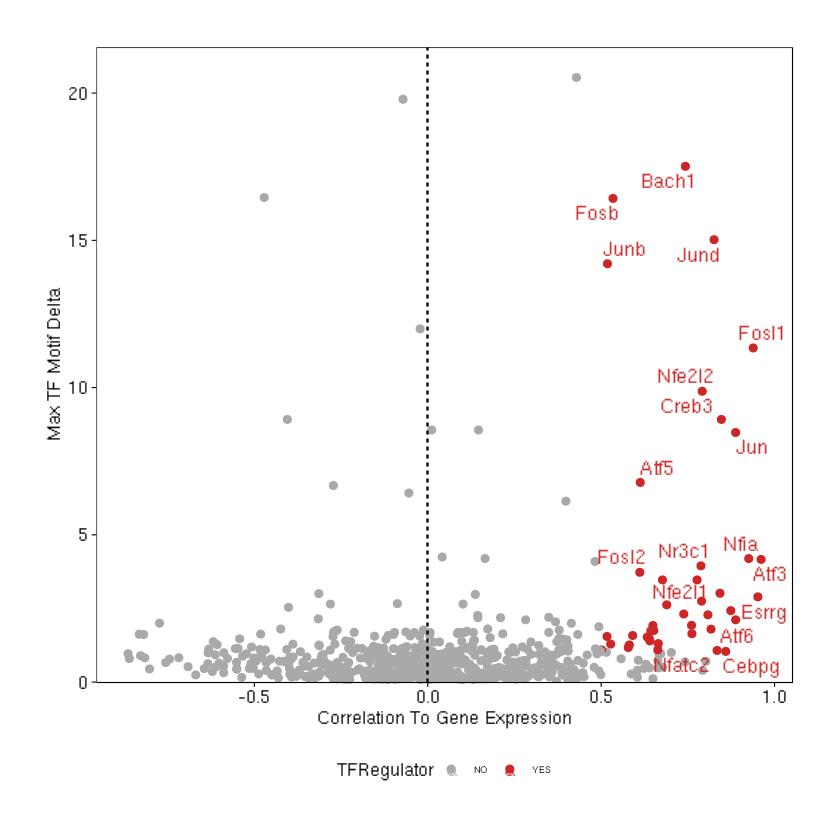

In [2]:
proj_alpha_corGEM_MM <- read.csv(project_path("proj_alpha_corGEM_MM.csv"))
corGEM_MM <- proj_alpha_corGEM_MM

pos_TF_regs <- ggplot(data.frame(corGEM_MM), aes(cor, maxDelta, color = TFRegulator, label = GeneExpressionMatrix_name)) +
  geom_point() +
  geom_text_repel(data = data.frame(subset(corGEM_MM, TFRegulator == "YES")))+
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") +
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Expression") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0),
    limits = c(0, max(corGEM_MM$maxDelta)*1.05)
  )

pos_TF_regs

## CellOracle plot

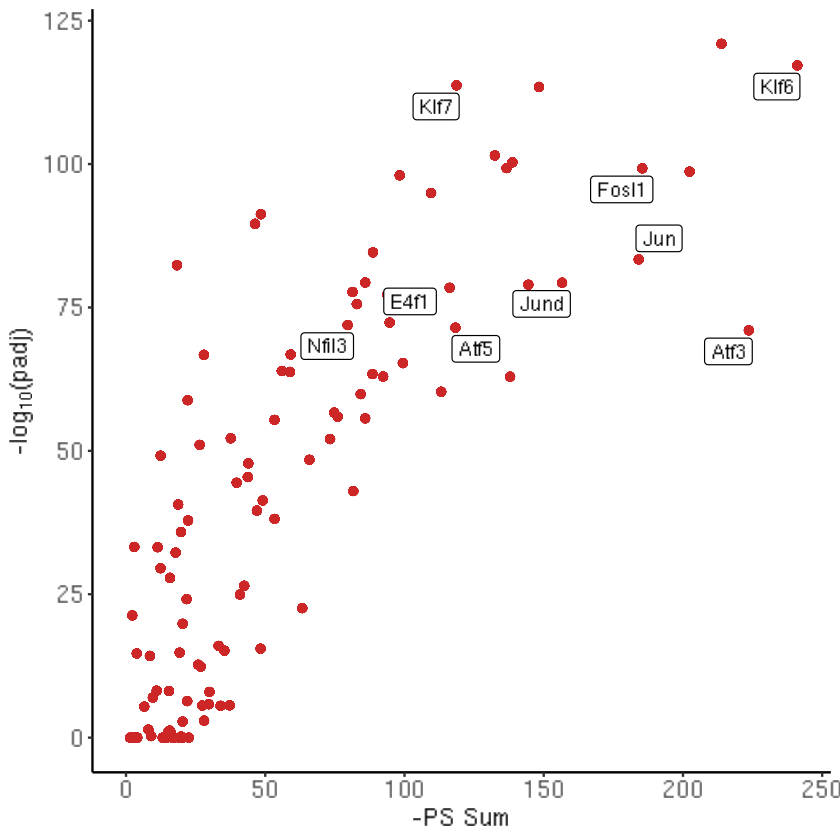

In [3]:
celloracle_DAMN_to_nonDAMN <- read.csv(file.path(CELLORACLE_DIR, "degen_to_nondegen_perturbation_score_result.csv"), row.names = 1)

make_half_volcano_plot <- function(data,
                                   labeled_pts,
                                   labeled_genes = character(0),
                                   p_val_cutoff = 0.01) {
  # Classify points by significance 
  data <- data %>%
    mutate(
      Expression = case_when(
        p_adj <= p_val_cutoff ~ "Significant",
        TRUE                  ~ "Unchanged"
      )
    )
  
  # Pick top points to label + any forced genes
  top_genes <- bind_rows(
    data %>%
      filter(Expression == "Significant") %>%
      arrange(p_adj, desc(ps_sum)) %>%
      slice_head(n = labeled_pts),
    data %>%
      filter(gene %in% labeled_genes)
  )
  
  # Define x-axis limit
  x_max <- max(data$ps_sum, na.rm = TRUE)
  
  # Build the plot
  ggplot(data, aes(x = ps_sum, y = -log10(p_adj))) +
    geom_point(aes(color = Expression), size = 2.2313) +
    geom_label_repel(
      data    = top_genes,
      aes(label = gene),
      size    = 4,
      max.overlaps = 18
    ) +
    # half-volcano: only from 0 -> max
    xlim(0, x_max) +
    xlab("-PS Sum") +
    ylab(expression("-log"[10]*"(padj)")) +
    scale_color_manual(
      values = c(Unchanged = "gray50", Significant = "firebrick3")
    ) +
    guides(colour = guide_legend(override.aes = list(size = 1.5))) +
    theme_classic() +
    theme(
      axis.text  = element_text(size = 14),
      axis.title = element_text(size = 14)
    )
}

alpha_DAMN_status_posTFregs <- c('Ar','Atf1','Atf3','Atf5','Atf6','Bach1','Bhlhe40','Bhlhe41','Cebpg','Creb3','Crem','E4f1','Esrra','Esrrb','Esrrg','Fosb','Fosl1','Fosl2','Gmeb2','Hbp1','Hoxc8','Jun','Junb','Jund','Klf13','Klf4','Klf6','Klf7','Nfatc2','Nfatc3','Nfe2l1','Nfe2l2','Nfe2l3','Nfia','Nfil3','Nr2f6','Nr3c1','Nr4a1','Sox5','Tcf4','Xbp1')
celloracle_DAMN_to_nonDAMN_top40 <- celloracle_DAMN_to_nonDAMN %>% slice_head(n = 40)
celloracle_chromVar_shared_TFs <- intersect(celloracle_DAMN_to_nonDAMN_top40$gene, alpha_DAMN_status_posTFregs)

celloracle_disease_volcano_plot <- make_half_volcano_plot(celloracle_DAMN_to_nonDAMN, 0, labeled_genes=celloracle_chromVar_shared_TFs, p_val_cutoff = 1) 
celloracle_disease_volcano_plot <- rasterize(celloracle_disease_volcano_plot, layers="Point", dpi=1000) + NoLegend()
celloracle_disease_volcano_plot

### Heatmap

Warning message:
“The following 13 features were not found in the integrated assay: Klf6, Atf5, Cebpg, Ar, Atf1, Nfatc2, Fosl1, Nfil3, Klf7, Gmeb2, Atf6, Klf13, Bach1”


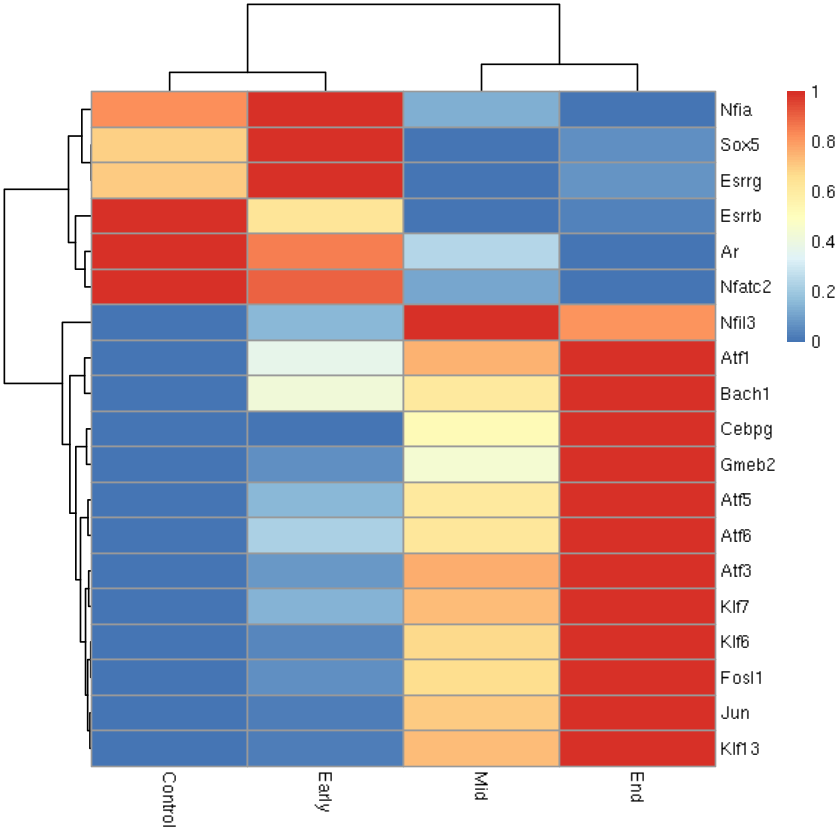

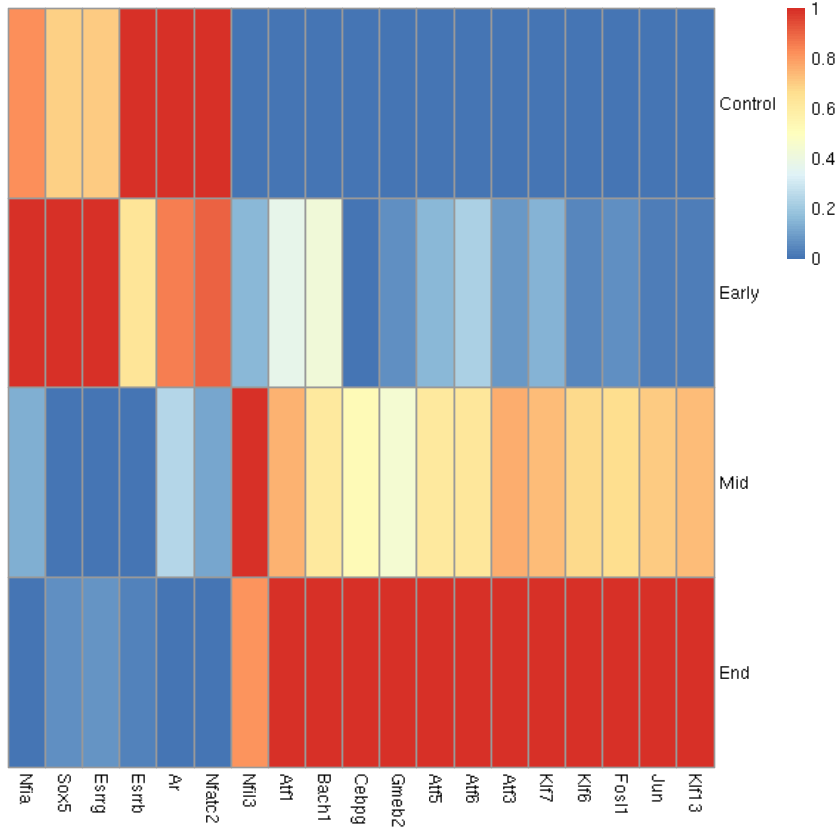

In [4]:
alpha_disease_diffexp_rnaOnly <- read.csv(file.path(SOD1_RNA_DIR, "DESeq2", "Cholinergic_Type", "Alpha MNs_sod.end_vs_ctl.csv"))

all.markers <- dplyr::filter(alpha_disease_diffexp_rnaOnly, X %in% alpha_DAMN_status_posTFregs & padj < 0.01)

alpha_label_transfer_50 <- readRDS(file.path(SOD1_RNA_DIR, "rds_files", "alpha_label_transfer_50.rds"))

Idents(alpha_label_transfer_50) <- alpha_label_transfer_50$stage
heatmap.avgexp <- AverageExpression(alpha_label_transfer_50, features=all.markers$X)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))

# define the mapping
new_names <- c(
  ctl        = "Control",
  sod.early  = "Early",
  sod.mid    = "Mid",
  sod.end    = "End"
)

# apply it to the matrix
colnames(heatmap.avgexp) <- new_names[colnames(heatmap.avgexp)]

pheatmap(heatmap.avgexp)

col_order <- c('Control','Early','Mid','End')
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c('Nfia','Sox5','Esrrg','Esrrb','Ar','Nfatc2','Nfil3','Atf1','Bach1','Cebpg',
               'Gmeb2','Atf5','Atf6','Atf3','Klf7','Klf6','Fosl1','Jun','Klf13')
heatmap.avgexp <- heatmap.avgexp[row_order,]

pheatmap(t(heatmap.avgexp), cluster_rows = FALSE, cluster_cols = FALSE)

### Motif deviations

In [5]:
#Load ArchR Project
proj_alpha <- loadArchRProject(project_path("proj_alpha"))

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [6]:
#Add DAMN status annotations
newLabels <- c('Late DAMN', ' Non-DAMN', ' Non-DAMN',  
               'Early DAMN', ' Non-DAMN')

oldLabels <- c('Late DAMN', 'Intermediate', 'Fast-Firing', 'Early DAMN', 'Slow-Firing')

proj_alpha$DAMN_status <- mapLabels(proj_alpha$alpha_subtype, newLabels = newLabels, oldLabels = oldLabels)


# Add impute weights
proj_alpha <- addImputeWeights(proj_alpha, reducedDims = "LSI_ATAC")

motifs <- c('Nfia','Sox5','Esrrg','Esrrb','Ar','Nfatc2','Nfil3','Atf1','Bach1','Cebpg',
            'Gmeb2','Atf5','Atf6','Atf3','Klf7','Klf6','Fosl1','Jun','Klf13','Creb3',
            'Xbp1','Nfe2l1','Nfe2l2','Nfe2l3')
markerMotifs <- getFeatures(proj_alpha, select = paste(motifs, collapse="|"), useMatrix = "MotifMatrix")
markerMotifs

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-12ad7f0642c0-Date-2026-06-22_Time-03-43-08.log
If there is an issue, please report to github with logFile!

2026-06-22 03:43:08 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



[1] "z:Nfe2l3_871"           "z:Creb3_870"            "z:Nfia_862"            
  [4] "z:Smarcc1_843"          "z:Klf13_817"            "z:Klf6_794"            
  [7] "z:Atf5_791"             "z:Batf3_789"            "z:Sox5_738"            
 [10] "z:Gmeb2_716"            "z:Nfatc2_700"           "z:Ar_687"              
 [13] "z:Rara_685"             "z:Esrrg_676"            "z:Ppara_670"           
 [16] "z:Esrrb_669"            "z:Rarb_663"             "z:Ppard_656"           
 [19] "z:Rarg_654"             "z:Pparg_653"            "z:Smarcc2_646"         
 [22] "z:Arx_500"              "z:Barhl2_492"           "z:Barx2_488"           
 [25] "z:Barhl1_457"           "z:Barx1_432"            "z:Klf7_171"            
 [28] "z:Nfil3_138"            "z:Nfil3_137"            "z:Jund_135"            
 [31] "z:Nfil3_131"            "z:Cebpg_129"            "z:Junb_127"            
 [34] "z:Jun_126"              "z:Creb3l2_118"          "z:Nfe2l1_117"          
 [37] "z:Creb3l3_116"          "z:Atf6_111"             "z:Atf3_110"            
 [40] "z:Bach1_108"            "z:Fosl1_107"            "z:Atf1_106"            
 [43] "z:Xbp1_103"             "z:Nfe2l2_101"           "z:Atf6b_100"           
 [46] "z:Arntl_89"             "z:Arnt2_26"             "z:Arnt_25"             
 [49] "z:Arid2_11"             "z:Arid3c_10"            "z:Arid5a_9"            
 [52] "z:Arid5b_8"             "z:Arid3a_7"             "z:Arid3b_6"            
 [55] "deviations:Nfe2l3_871"  "deviations:Creb3_870"   "deviations:Nfia_862"   
 [58] "deviations:Smarcc1_843" "deviations:Klf13_817"   "deviations:Klf6_794"   
 [61] "deviations:Atf5_791"    "deviations:Batf3_789"   "deviations:Sox5_738"   
 [64] "deviations:Gmeb2_716"   "deviations:Nfatc2_700"  "deviations:Ar_687"     
 [67] "deviations:Rara_685"    "deviations:Esrrg_676"   "deviations:Ppara_670"  
 [70] "deviations:Esrrb_669"   "deviations:Rarb_663"    "deviations:Ppard_656"  
 [73] "deviations:Rarg_654"    "deviations:Pparg_653"   "deviations:Smarcc2_646"
 [76] "deviations:Arx_500"     "deviations:Barhl2_492"  "deviations:Barx2_488"  
 [79] "deviations:Barhl1_457"  "deviations:Barx1_432"   "deviations:Klf7_171"   
 [82] "deviations:Nfil3_138"   "deviations:Nfil3_137"   "deviations:Jund_135"   
 [85] "deviations:Nfil3_131"   "deviations:Cebpg_129"   "deviations:Junb_127"   
 [88] "deviations:Jun_126"     "deviations:Creb3l2_118" "deviations:Nfe2l1_117" 
 [91] "deviations:Creb3l3_116" "deviations:Atf6_111"    "deviations:Atf3_110"   
 [94] "deviations:Bach1_108"   "deviations:Fosl1_107"   "deviations:Atf1_106"   
 [97] "deviations:Xbp1_103"    "deviations:Nfe2l2_101"  "deviations:Atf6b_100"  
[100] "deviations:Arntl_89"    "deviations:Arnt2_26"    "deviations:Arnt_25"    
[103] "deviations:Arid2_11"    "deviations:Arid3c_10"   "deviations:Arid5a_9"   
[106] "deviations:Arid5b_8"    "deviations:Arid3a_7"    "deviations:Arid3b_6"

Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:43:13 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad114b38b0-Date-2026-06-22_Time-03-43-14.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 
8 


Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:43:15 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad3d7565ee-Date-2026-06-22_Time-03-43-16.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 
8 


Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:43:17 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad5022f4c1-Date-2026-06-22_Time-03-43-18.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 
8 


Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”
Picking joint bandwid

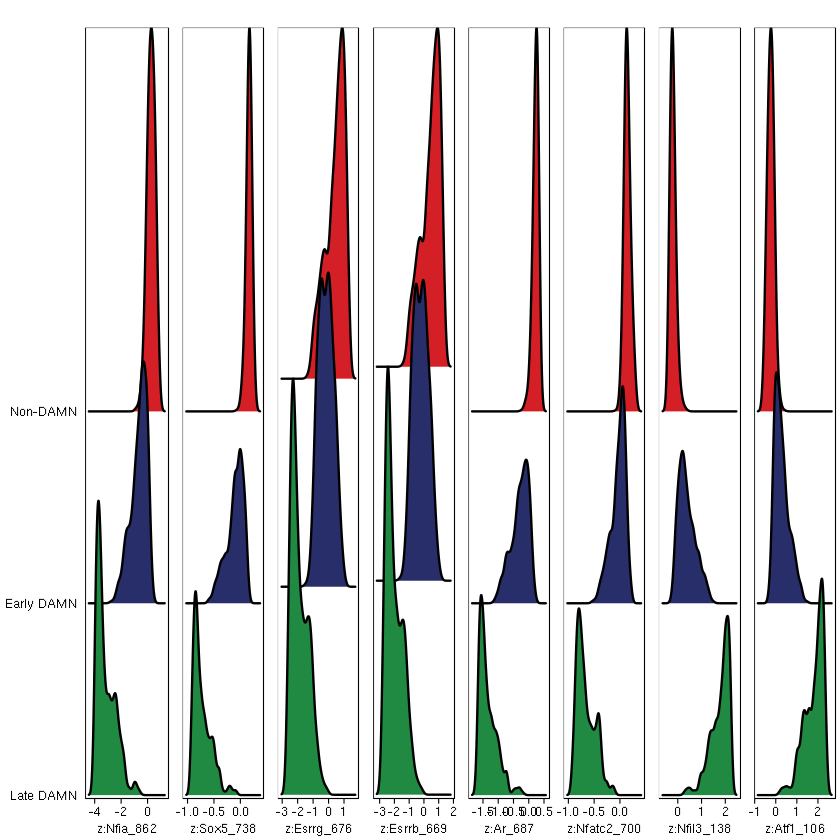

Picking joint bandwidth of 0.372

Picking joint bandwidth of 0.279

Picking joint bandwidth of 0.0718

Picking joint bandwidth of 0.275

Picking joint bandwidth of 0.0759

Picking joint bandwidth of 0.109

Picking joint bandwidth of 0.308

Picking joint bandwidth of 0.109



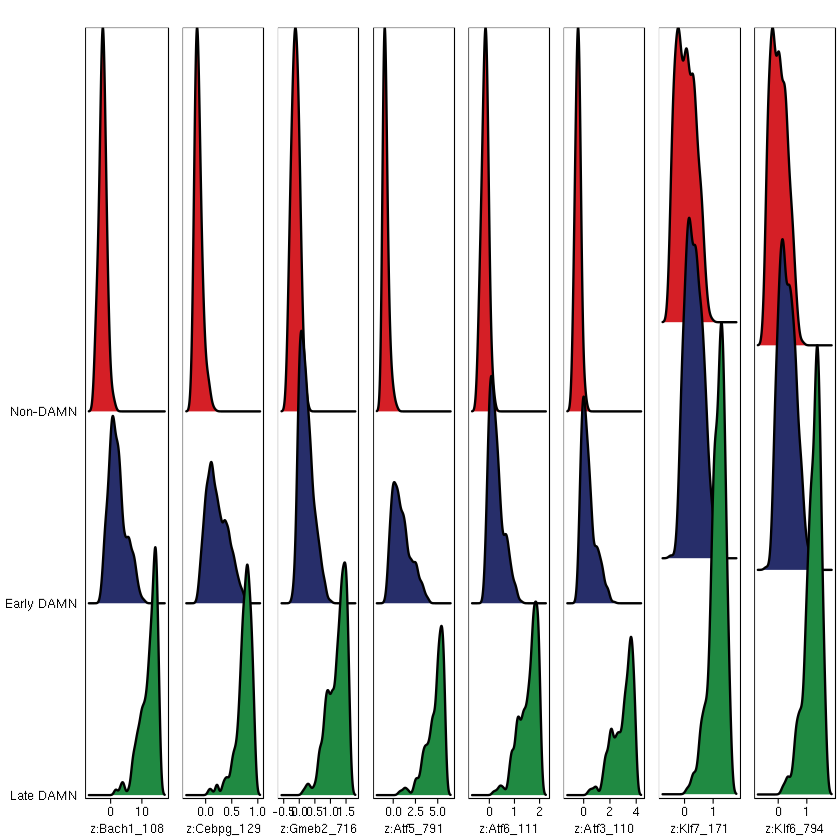

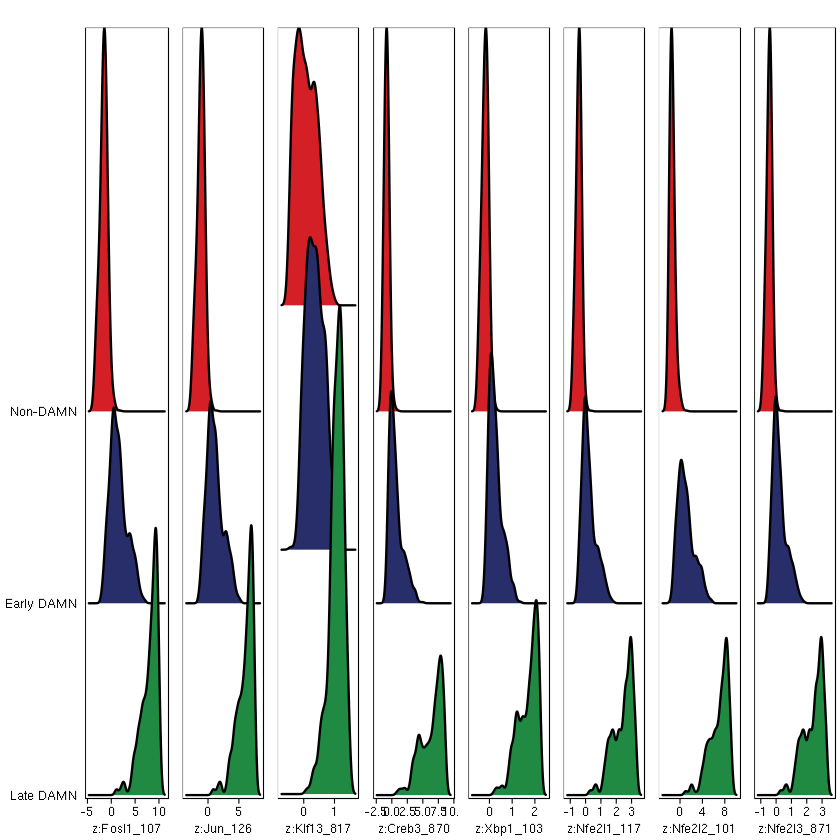

In [7]:
markerMotifs_1 <- c('z:Nfia_862','z:Sox5_738','z:Esrrg_676','z:Esrrb_669',
                    'z:Ar_687','z:Nfatc2_700','z:Nfil3_138','z:Atf1_106')
markerMotifs_2 <- c('z:Bach1_108','z:Cebpg_129','z:Gmeb2_716','z:Atf5_791',
                    'z:Atf6_111','z:Atf3_110','z:Klf7_171','z:Klf6_794')
markerMotifs_3 <- c('z:Fosl1_107','z:Jun_126','z:Klf13_817','z:Creb3_870',
                    'z:Xbp1_103','z:Nfe2l1_117','z:Nfe2l2_101','z:Nfe2l3_871')

p1 <- plotGroups(ArchRProj = proj_alpha, 
  groupBy = "DAMN_status", 
  colorBy = "MotifMatrix", 
  name = markerMotifs_1,
  imputeWeights = getImputeWeights(proj_alpha)
)

p2 <- plotGroups(ArchRProj = proj_alpha, 
  groupBy = "DAMN_status", 
  colorBy = "MotifMatrix", 
  name = markerMotifs_2,
  imputeWeights = getImputeWeights(proj_alpha)
)

p3 <- plotGroups(ArchRProj = proj_alpha, 
  groupBy = "DAMN_status", 
  colorBy = "MotifMatrix", 
  name = markerMotifs_3,
  imputeWeights = getImputeWeights(proj_alpha)
)

p4 <- lapply(seq_along(p1), function(x){
  if(x != 1){
    p1[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p1[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p4 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(1.8182, rep(1, length(p4) - 1))),p4))
p4

p5 <- lapply(seq_along(p2), function(x){
  if(x != 1){
    p2[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p2[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p5 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(1.8182, rep(1, length(p5) - 1))),p5))
p5

p6 <- lapply(seq_along(p3), function(x){
  if(x != 1){
    p3[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p3[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p6 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(1.8182, rep(1, length(p6) - 1))),p6))
p6

## Control skeletal MN subtype plots

### Positive TF regulators plot

Warning message:
“Removed 188 rows containing missing values (`geom_point()`).”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


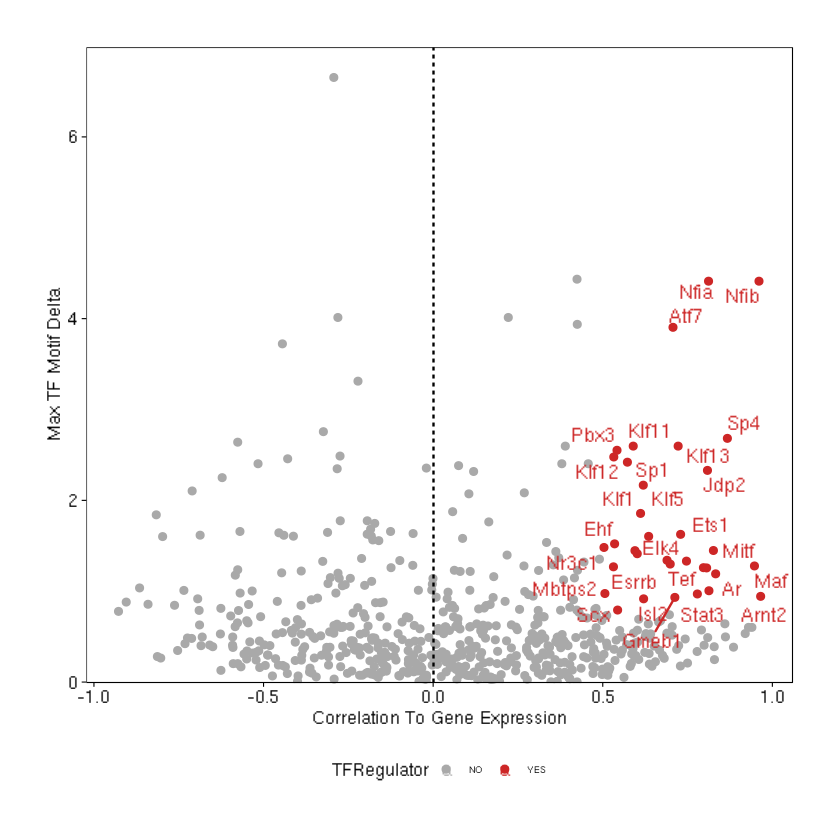

In [8]:
proj_skeletal_ctl_corGEM_MM <- read.csv(project_path("proj_skeletal_ctl_corGEM_MM.csv"))
corGEM_MM <- proj_skeletal_ctl_corGEM_MM

pos_TF_regs_skeletal_type <- ggplot(data.frame(corGEM_MM), aes(cor, maxDelta, color = TFRegulator, label = GeneExpressionMatrix_name)) +
  geom_point() +
  geom_text_repel(data = data.frame(subset(corGEM_MM, TFRegulator == "YES")))+
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") +
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Expression") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0),
    limits = c(0, max(corGEM_MM$maxDelta)*1.05)
  )

pos_TF_regs_skeletal_type

### Heatmap

Warning message:
“The following 12 features were not found in the integrated assay: Arnt2, Ehf, Klf5, Arntl, Pou3f3, Ar, Klf11, Scx, Stat3, Rest, Elk4, Sp4”


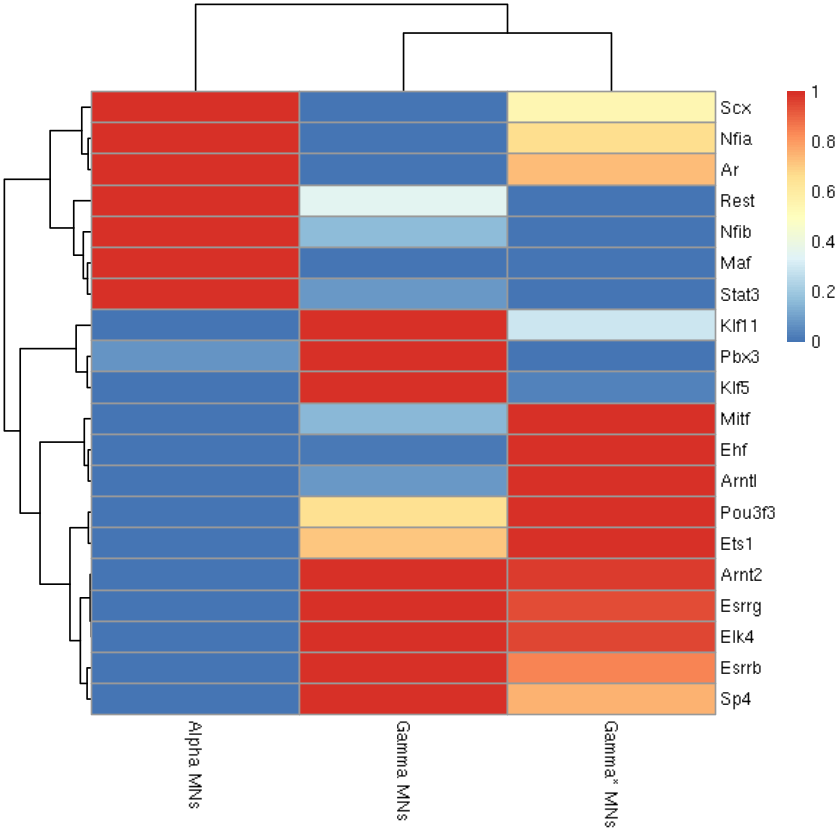

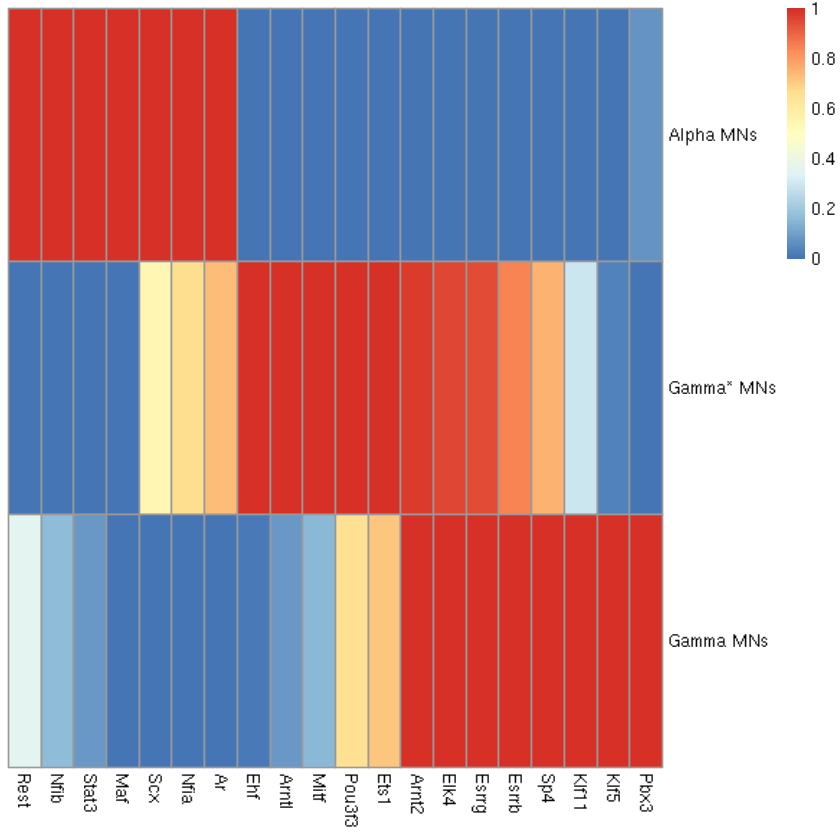

In [9]:
cholinergic_annotated <- readRDS(file.path(SOD1_RNA_DIR, "rds_files", "cholinergic_annotated.rds"))

cholinergic_ctl <- subset(cholinergic_annotated, subset = stage == "ctl")
skeletal_ctl <- subset(cholinergic_ctl, subset = cholinergic_type %in% c('Alpha MNs','Gamma Star MNs','Gamma MNs'))

all.markers <- c('Esrrb','Maf','Arnt2','Pbx3','Nfib','Esrrg','Ehf','Mitf','Klf5','Arntl','Pou3f3','Nfia','Ar',
                 'Klf11','Scx','Ets1','Stat3','Rest','Elk4','Sp4')

Idents(skeletal_ctl) <- skeletal_ctl$cholinergic_type
heatmap.avgexp <- AverageExpression(skeletal_ctl, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))

# define the mapping
new_names <- c(
  `Alpha MNs`      = "Alpha MNs",
  `Gamma MNs`      = "Gamma MNs",
  `Gamma Star MNs` = "Gamma* MNs"
)

# apply it to the matrix
colnames(heatmap.avgexp) <- new_names[colnames(heatmap.avgexp)]

pheatmap(heatmap.avgexp)

col_order <- c('Alpha MNs','Gamma* MNs','Gamma MNs')
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c('Rest','Nfib','Stat3','Maf','Scx','Nfia','Ar','Ehf','Arntl','Mitf','Pou3f3','Ets1','Arnt2',
               'Elk4','Esrrg','Esrrb','Sp4','Klf11','Klf5','Pbx3')
heatmap.avgexp <- heatmap.avgexp[row_order,]

pheatmap(t(heatmap.avgexp), cluster_rows = FALSE, cluster_cols = FALSE)

### Motif deviations

In [10]:
#Load ArchR Project
proj_skeletal_ctl <- loadArchRProject(project_path("proj_skeletal_ctl"))

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [11]:
# Add impute weights
proj_skeletal_ctl <- addImputeWeights(
  ArchRProj = proj_skeletal_ctl,
  reducedDims = "LSI_ATAC"
)

motifs <- c(
  "Stat3", "Nfib", "Maf", "Ar", "Isl2", "Nfia",
  "Mitf", "Arntl", "Esrrg", "Esrrb", "Arnt2", "Pbx3"
)

markerMotifs <- getFeatures(
  ArchRProj = proj_skeletal_ctl,
  select = paste(motifs, collapse = "|"),
  useMatrix = "MotifMatrix"
)

markerMotifs

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-12ad6bff27dc-Date-2026-06-22_Time-03-44-45.log
If there is an issue, please report to github with logFile!

2026-06-22 03:44:46 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



[1] "z:Nfia_862"             "z:Nfib_859"             "z:Smarcc1_843"         
 [4] "z:Maf_793"              "z:Mafa_792"             "z:Stat3_754"           
 [7] "z:Ar_687"               "z:Rara_685"             "z:Esrrg_676"           
[10] "z:Ppara_670"            "z:Esrrb_669"            "z:Rarb_663"            
[13] "z:Ppard_656"            "z:Rarg_654"             "z:Pparg_653"           
[16] "z:Smarcc2_646"          "z:Pbx3_513"             "z:Arx_500"             
[19] "z:Barhl2_492"           "z:Isl2_489"             "z:Barx2_488"           
[22] "z:Barhl1_457"           "z:Barx1_432"            "z:Mafb_136"            
[25] "z:Mafg_123"             "z:Mafk_102"             "z:Arntl_89"            
[28] "z:Mitf_62"              "z:Arnt2_26"             "z:Arnt_25"             
[31] "z:Arid2_11"             "z:Arid3c_10"            "z:Arid5a_9"            
[34] "z:Arid5b_8"             "z:Arid3a_7"             "z:Arid3b_6"            
[37] "deviations:Nfia_862"    "deviations:Nfib_859"    "deviations:Smarcc1_843"
[40] "deviations:Maf_793"     "deviations:Mafa_792"    "deviations:Stat3_754"  
[43] "deviations:Ar_687"      "deviations:Rara_685"    "deviations:Esrrg_676"  
[46] "deviations:Ppara_670"   "deviations:Esrrb_669"   "deviations:Rarb_663"   
[49] "deviations:Ppard_656"   "deviations:Rarg_654"    "deviations:Pparg_653"  
[52] "deviations:Smarcc2_646" "deviations:Pbx3_513"    "deviations:Arx_500"    
[55] "deviations:Barhl2_492"  "deviations:Isl2_489"    "deviations:Barx2_488"  
[58] "deviations:Barhl1_457"  "deviations:Barx1_432"   "deviations:Mafb_136"   
[61] "deviations:Mafg_123"    "deviations:Mafk_102"    "deviations:Arntl_89"   
[64] "deviations:Mitf_62"     "deviations:Arnt2_26"    "deviations:Arnt_25"    
[67] "deviations:Arid2_11"    "deviations:Arid3c_10"   "deviations:Arid5a_9"   
[70] "deviations:Arid5b_8"    "deviations:Arid3a_7"    "deviations:Arid3b_6"

Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:44:51 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad6edc87db-Date-2026-06-22_Time-03-44-53.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 


Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:44:55 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad4a5cf211-Date-2026-06-22_Time-03-44-56.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 


Picking joint bandwidth of 0.0288

Picking joint bandwidth of 0.0672

Picking joint bandwidth of 0.0143

Picking joint bandwidth of 0.0352

Picking joint bandwidth of 0.0137

Picking joint bandwidth of 0.0672

Picking joint bandwidth of 0.0205

Picking joint bandwidth of 0.0248

Picking joint bandwidth of 0.0261

Picking joint bandwidth of 0.0278

Picking joint bandwidth of 0.0186

Picking joint bandwidth o

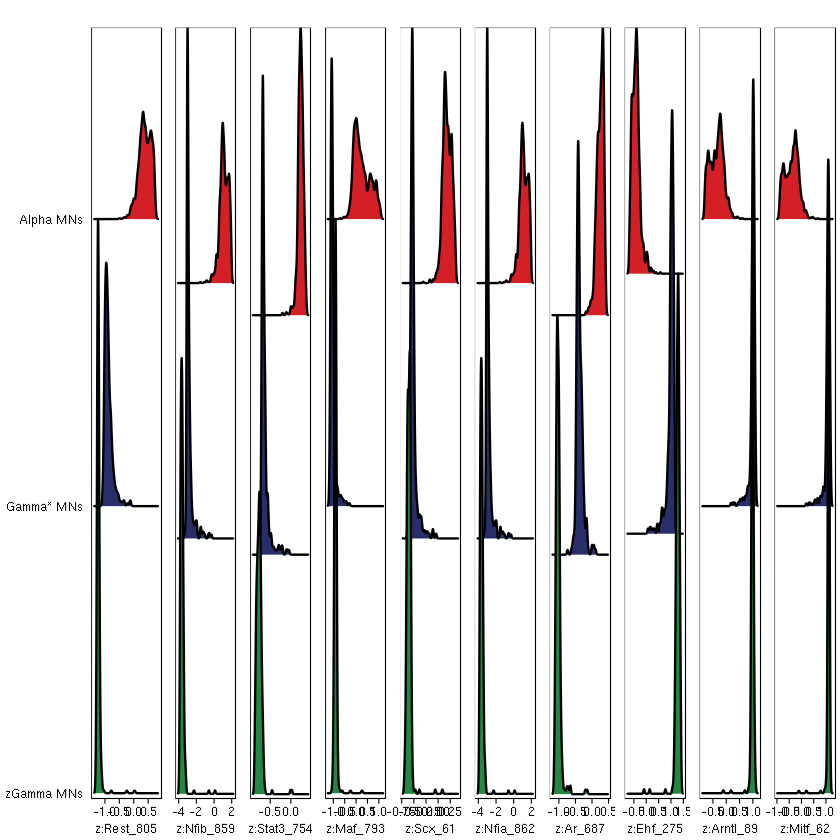

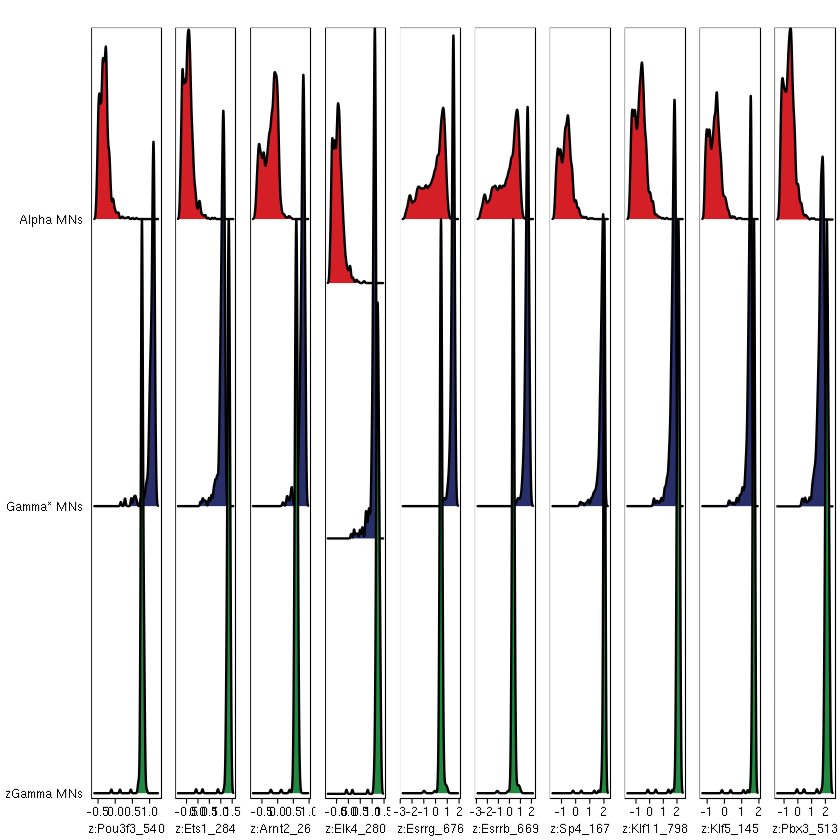

In [12]:
markerMotifs_1 <- c('z:Rest_805','z:Nfib_859','z:Stat3_754','z:Maf_793','z:Scx_61','z:Nfia_862','z:Ar_687',
                    'z:Ehf_275','z:Arntl_89','z:Mitf_62')
markerMotifs_2 <- c('z:Pou3f3_540','z:Ets1_284','z:Arnt2_26','z:Elk4_280','z:Esrrg_676','z:Esrrb_669',
                    'z:Sp4_167','z:Klf11_798','z:Klf5_145','z:Pbx3_513')

# Add modified cholinergic type annotations
newLabels <- c("Alpha MNs", "Gamma* MNs", "zGamma MNs")
oldLabels <- c("Alpha MNs", "Gamma* MNs", "Gamma MNs")

proj_skeletal_ctl$cholinergic_type_mod <- mapLabels(
  proj_skeletal_ctl$cholinergic_type,
  newLabels = newLabels,
  oldLabels = oldLabels
)

p1 <- plotGroups(
  ArchRProj = proj_skeletal_ctl,
  groupBy = "cholinergic_type_mod",
  colorBy = "MotifMatrix",
  name = markerMotifs_1,
  imputeWeights = getImputeWeights(proj_skeletal_ctl)
)

p2 <- plotGroups(
  ArchRProj = proj_skeletal_ctl,
  groupBy = "cholinergic_type_mod",
  colorBy = "MotifMatrix",
  name = markerMotifs_2,
  imputeWeights = getImputeWeights(proj_skeletal_ctl)
)

p3 <- lapply(seq_along(p1), function(x){
  if(x != 1){
    p1[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p1[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p3 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2.2134, rep(1, length(p3) - 1))),p3))
p3

p4 <- lapply(seq_along(p2), function(x){
  if(x != 1){
    p2[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p2[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p4 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2.2134, rep(1, length(p4) - 1))),p4))
p4

## Control alpha MN subtype plots

### Positive TF regulators plot

Warning message:
“Removed 205 rows containing missing values (`geom_point()`).”
Warning message:
“ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


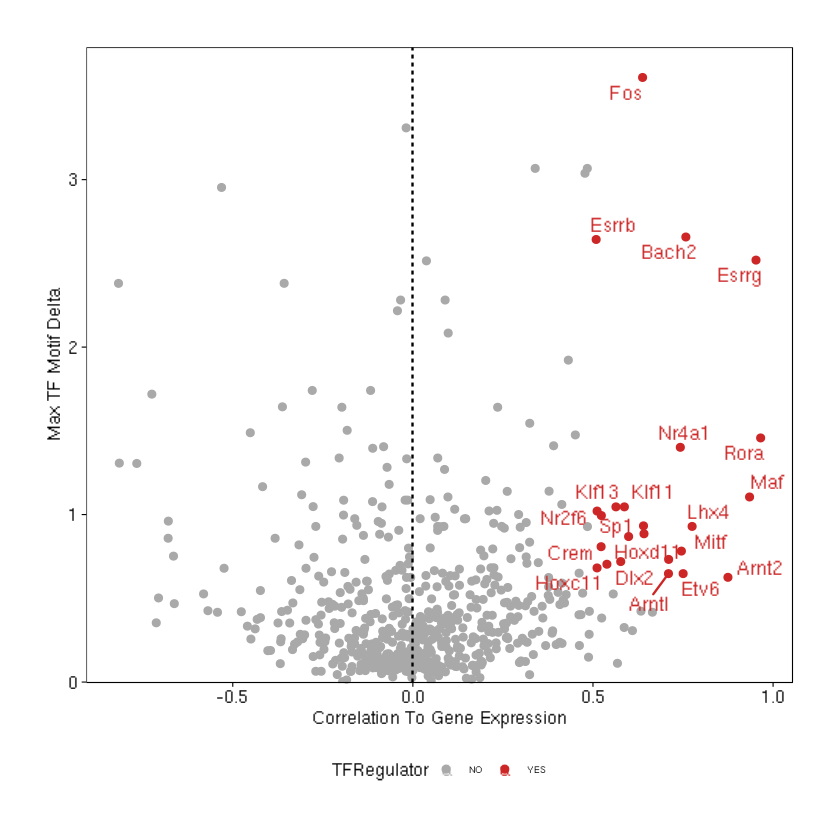

In [13]:
proj_control_FF_Int_SF_corGEM_MM <- read.csv(project_path("proj_control_FF_Int_SF_corGEM_MM.csv"))
corGEM_MM <- proj_control_FF_Int_SF_corGEM_MM

pos_TF_regs_subtype <- ggplot(data.frame(corGEM_MM), aes(cor, maxDelta, color = TFRegulator, label = GeneExpressionMatrix_name)) +
  geom_point() +
  geom_text_repel(data = data.frame(subset(corGEM_MM, TFRegulator == "YES")))+
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") +
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Expression") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0),
    limits = c(0, max(corGEM_MM$maxDelta)*1.05)
  )

pos_TF_regs_subtype

### CellOracle plot

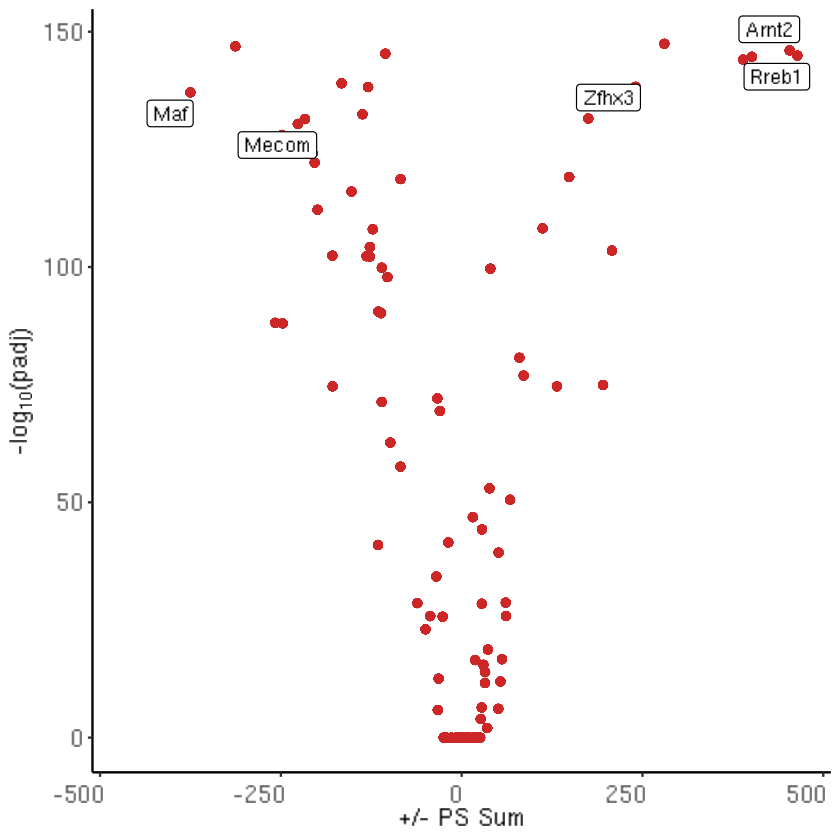

In [14]:
celloracle_fast_to_slow <- read.csv(file.path(CELLORACLE_DIR, "fast_to_slow_perturbation_score_result.csv"), row.names = 1)
celloracle_slow_to_fast <- read.csv(file.path(CELLORACLE_DIR, "slow_to_fast_perturbation_score_result.csv"), row.names = 1)

celloracle_fast_to_slow <- celloracle_fast_to_slow %>% mutate(ps_sum = -ps_sum)
celloracle_fast_slow <- dplyr::bind_rows(celloracle_fast_to_slow, celloracle_slow_to_fast)

make_volcano_plot <- function(data,
                              labeled_pts,
                              labeled_genes = character(0),
                              p_val_cutoff = 0.01) {
  # Classify points by significance only
  data <- data %>%
    mutate(
      Expression = case_when(
        p_adj <= p_val_cutoff ~ "Significant",
        TRUE                  ~ "Unchanged"
      )
    )
  
  # Top significant points 
  sig_pts <- data %>%
    filter(Expression == "Significant") %>%
    arrange(p_adj, desc(abs(ps_sum))) %>% 
    slice_head(n = labeled_pts)
  
  # Labeled genes, but only keep the copy with the highest -log10(p_adj)
  forced_pts <- data %>%
    filter(gene %in% labeled_genes) %>%
    group_by(gene) %>%
    slice_max(-log10(p_adj), n = 1) %>%
    ungroup()
  
  # Combine and drop any remaining duplicates,
  # Keeping the one with the greatest -log10(p_adj)
  top_genes <- bind_rows(sig_pts, forced_pts) %>%
    group_by(gene) %>%
    slice_max(-log10(p_adj), n = 1) %>%
    ungroup()
  
  # Symmetric x-axis limit
  x_max <- max(abs(data$ps_sum), na.rm = TRUE)
  
  # Build the plot
  ggplot(data, aes(x = ps_sum, y = -log10(p_adj))) +
    geom_point(aes(color = Expression), size = 2.2313) +
    geom_label_repel(
      data         = top_genes,
      aes(label    = gene),
      size         = 4,
      max.overlaps = 18
    ) +
    xlim(-x_max, x_max) +
    xlab("+/- PS Sum") +
    ylab(expression("-log"[10]*"(padj)")) +
    scale_color_manual(
      values = c(Unchanged = "gray50", Significant = "firebrick3")
    ) +
    guides(colour = guide_legend(override.aes = list(size = 1.5))) +
    theme_classic() +
    theme(
      axis.text   = element_text(size = 14),
      axis.title  = element_text(size = 14),
      axis.text.x = element_text(angle = 0, vjust = 0, hjust = 0.9)
    )
}


celloracle_fast_slow_volcano_plot <- make_volcano_plot(celloracle_fast_slow, 0, labeled_genes=c("Maf","Mecom","Rreb1","Arnt2","Zfhx3"), p_val_cutoff = 1) 
celloracle_fast_slow_volcano_plot <- rasterize(celloracle_fast_slow_volcano_plot, layers="Point", dpi=1000) + NoLegend()
celloracle_fast_slow_volcano_plot

### Heatmap

Warning message in PseudobulkExpression(object = object, pb.method = "average", :
“Exponentiation yielded infinite values. `data` may not be log-normed.”
Warning message:
“The following 4 features were not found in the integrated assay: Nr4a1, Arntl, Nr2f1, Arnt2”


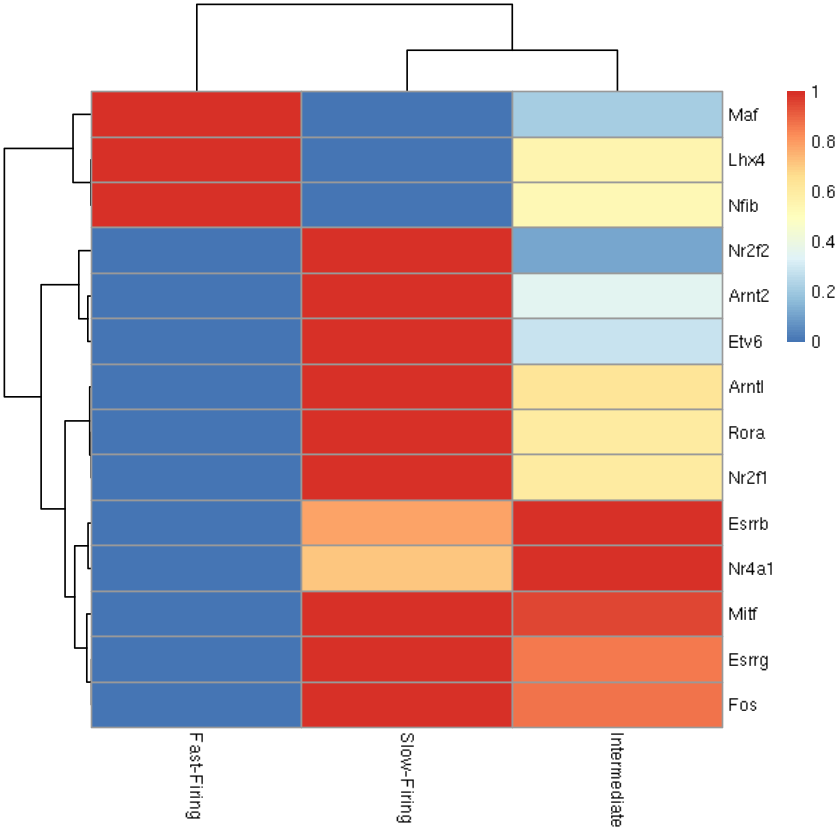

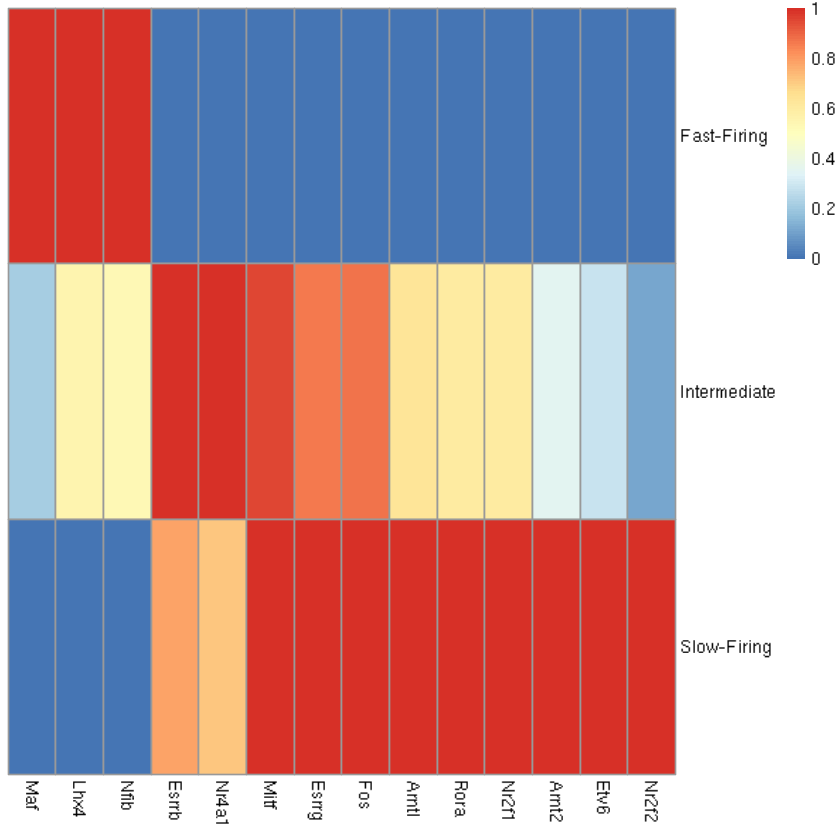

In [15]:
alpha_label_transfer_50 <- readRDS(file.path(SOD1_RNA_DIR, "rds_files", "alpha_label_transfer_50.rds"))

alpha_label_transfer_50_filtered <- subset(alpha_label_transfer_50, stage == "ctl")
alpha_label_transfer_50_filtered <- subset(alpha_label_transfer_50_filtered, predicted.id %in% c('Slow-Firing','Fast-Firing','Intermediate'))

all.markers <- c('Maf','Lhx4','Nfib','Esrrb','Nr4a1','Mitf','Esrrg','Fos','Arntl','Rora',
               'Nr2f1','Arnt2','Etv6','Nr2f2')

Idents(alpha_label_transfer_50_filtered) <- alpha_label_transfer_50_filtered$predicted.id
heatmap.avgexp <- AverageExpression(alpha_label_transfer_50_filtered, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))

pheatmap(heatmap.avgexp)

row_order <- c('Fast-Firing','Intermediate','Slow-Firing')
heatmap.avgexp <- heatmap.avgexp[,row_order]

col_order <- c('Maf','Lhx4','Nfib','Esrrb','Nr4a1','Mitf','Esrrg','Fos','Arntl','Rora',
               'Nr2f1','Arnt2','Etv6','Nr2f2')
heatmap.avgexp <- heatmap.avgexp[col_order,]

pheatmap(t(heatmap.avgexp), cluster_rows = FALSE, cluster_cols = FALSE)

### Motif deviations

In [16]:
#Load ArchR Project
proj_control_FF_Int_SF <- loadArchRProject(project_path("proj_control_FF_Int_SF"))

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [17]:
# Add impute weights
proj_control_FF_Int_SF <- addImputeWeights(
  ArchRProj = proj_control_FF_Int_SF,
  reducedDims = "LSI_ATAC"
)

motifs <- c('Maf','Lhx4','Nfib','Esrrb','Nr4a1','Mitf','Esrrg','Fos','Arntl','Rora','Nr2f1','Arnt2','Etv6','Nr2f2')

markerMotifs <- getFeatures(
  ArchRProj = proj_control_FF_Int_SF,
  select = paste(motifs, collapse = "|"),
  useMatrix = "MotifMatrix"
)

markerMotifs

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-12ad43379755-Date-2026-06-22_Time-03-45-32.log
If there is an issue, please report to github with logFile!

2026-06-22 03:45:32 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



[1] "z:Nfib_859"           "z:Nr4a1_847"          "z:Maf_793"           
 [4] "z:Mafa_792"           "z:Nr2f1_690"          "z:Rora_682"          
 [7] "z:Nr2f2_680"          "z:Esrrg_676"          "z:Esrrb_669"         
[10] "z:Lhx4_454"           "z:Etv6_282"           "z:Mafb_136"          
[13] "z:Mafg_123"           "z:Fosl2_113"          "z:Fosl1_107"         
[16] "z:Fos_104"            "z:Mafk_102"           "z:Fosb_98"           
[19] "z:Arntl_89"           "z:Mitf_62"            "z:Arnt2_26"          
[22] "deviations:Nfib_859"  "deviations:Nr4a1_847" "deviations:Maf_793"  
[25] "deviations:Mafa_792"  "deviations:Nr2f1_690" "deviations:Rora_682" 
[28] "deviations:Nr2f2_680" "deviations:Esrrg_676" "deviations:Esrrb_669"
[31] "deviations:Lhx4_454"  "deviations:Etv6_282"  "deviations:Mafb_136" 
[34] "deviations:Mafg_123"  "deviations:Fosl2_113" "deviations:Fosl1_107"
[37] "deviations:Fos_104"   "deviations:Mafk_102"  "deviations:Fosb_98"  
[40] "deviations:Arntl_89"  "deviations:Mitf_62"   "deviations:Arnt2_26"

Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:45:35 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad655218d4-Date-2026-06-22_Time-03-45-37.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 


Getting ImputeWeights

Getting Matrix Values...

2026-06-22 03:45:38 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12ad5f55f648-Date-2026-06-22_Time-03-45-40.log
If there is an issue, please report to github with logFile!

Using weights on disk

1 of 1

1 
2 
3 
4 
5 
6 
7 


Picking joint bandwidth of 0.0269

Picking joint bandwidth of 0.0246

Picking joint bandwidth of 0.0271

Picking joint bandwidth of 0.0619

Picking joint bandwidth of 0.0345

Picking joint bandwidth of 0.0253

Picking joint bandwidth of 0.0606

Picking joint bandwidth of 0.0734

Picking joint bandwidth of 0.0223

Picking joint bandwidth of 0.0356

Picking joint bandwidth of 0.0228

Picking joint bandwidth of 0.0182

Picking jo

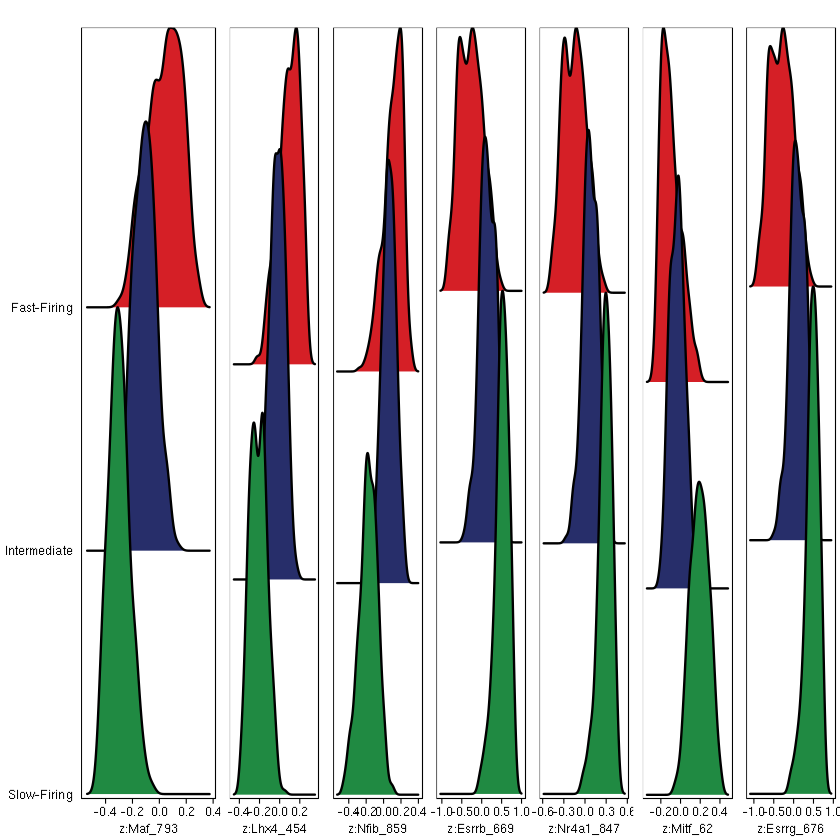

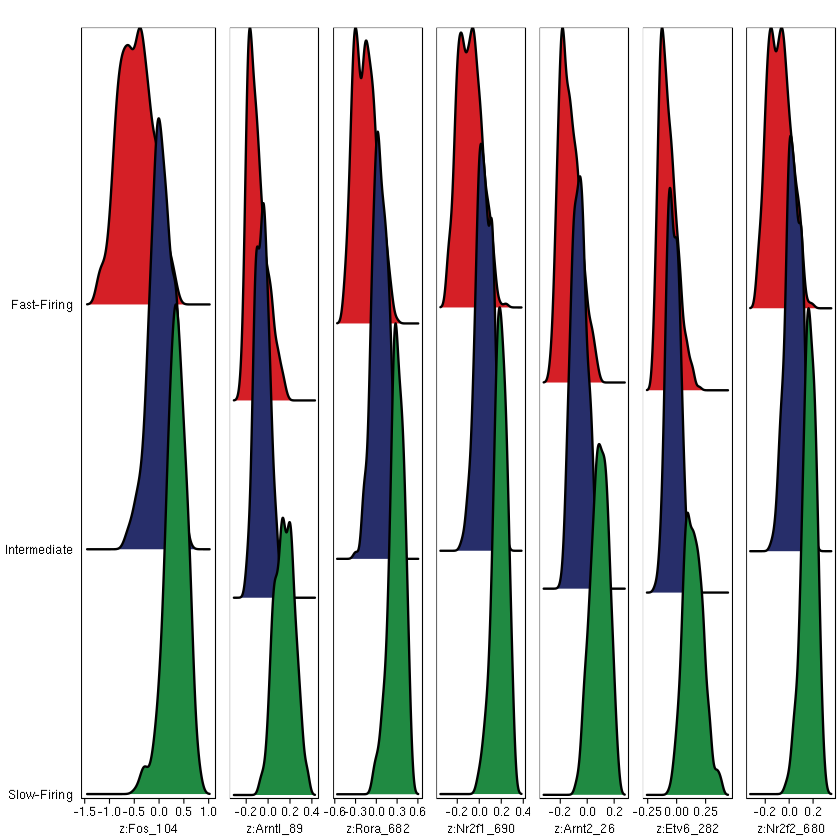

In [18]:
markerMotifs_1 <- c('z:Maf_793','z:Lhx4_454','z:Nfib_859','z:Esrrb_669','z:Nr4a1_847','z:Mitf_62','z:Esrrg_676')
markerMotifs_2 <- c('z:Fos_104','z:Arntl_89','z:Rora_682','z:Nr2f1_690','z:Arnt2_26','z:Etv6_282','z:Nr2f2_680')

p1 <- plotGroups(ArchRProj = proj_control_FF_Int_SF, 
  groupBy = "alpha_subtype", 
  colorBy = "MotifMatrix", 
  name = markerMotifs_1,
  imputeWeights = getImputeWeights(proj_control_FF_Int_SF)
)

p2 <- plotGroups(ArchRProj = proj_control_FF_Int_SF, 
  groupBy = "alpha_subtype", 
  colorBy = "MotifMatrix", 
  name = markerMotifs_2,
  imputeWeights = getImputeWeights(proj_control_FF_Int_SF)
)

p3 <- lapply(seq_along(p1), function(x){
  if(x != 1){
    p1[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p1[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p3 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2.1347, rep(1, length(p3) - 1))),p3))
p3

p4 <- lapply(seq_along(p2), function(x){
  if(x != 1){
    p2[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p2[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 7) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})

p4 <- do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2.1347, rep(1, length(p4) - 1))),p4))
p4